## Imports & Config

In [1]:
# !pip install librosa numpy scikit-learn matplotlib

import os
import joblib
import numpy as np
import librosa
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

DATA_DIR    = "dataset_voice"   # subfolders: angry/ happy/ sad/
EMOTIONS    = ["angry", "happy", "sad"]
SAMPLE_RATE = 22050
DURATION    = 3.0
N_MFCC      = 13
TEST_SIZE   = 0.2
RANDOM_SEED = 42

## Feature Extraction

In [2]:
def extract_features(file_path):
    audio, _ = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION, mono=True)

    # Pad if shorter than target duration
    target_len = int(SAMPLE_RATE * DURATION)
    if len(audio) < target_len:
        audio = np.pad(audio, (0, target_len - len(audio)))

    # MFCC — 13 coefficients, mean across time
    mfccs = librosa.feature.mfcc(y=audio, sr=SAMPLE_RATE, n_mfcc=N_MFCC)
    mfcc_mean = np.mean(mfccs, axis=1)

    # Pitch (F0) — yin algorithm (no Numba required)
    f0 = librosa.yin(
        audio,
        fmin=librosa.note_to_hz("C2"),
        fmax=librosa.note_to_hz("C7")
    )
    pitch_mean = float(np.mean(f0))

    # Energy (RMS)
    energy_mean = float(np.mean(librosa.feature.rms(y=audio)))

    # Final feature vector: 13 MFCCs + pitch + energy = 15 values
    return np.append(mfcc_mean, [pitch_mean, energy_mean])

## Build Dataset

In [3]:
X, y = [], []

for emotion in EMOTIONS:
    folder = os.path.join(DATA_DIR, emotion)
    files  = [f for f in os.listdir(folder) if f.endswith((".wav", ".mp3", ".flac"))]
    print(f"{emotion}: {len(files)} files")
    for fname in files:
        try:
            X.append(extract_features(os.path.join(folder, fname)))
            y.append(emotion)
        except Exception as e:
            print(f"  [skip] {fname} — {e}")

X = np.array(X)
print(f"\nTotal: {len(y)} samples | Feature vector size: {X.shape[1]}")

angry: 2167 files
happy: 2167 files
sad: 2167 files

Total: 6501 samples | Feature vector size: 15


## Train / Test Split & Scaling

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train: {len(y_train)}  |  Test: {len(y_test)}")

Train: 5200  |  Test: 1301


## SVM

In [ ]:
svm = SVC(kernel="rbf", C=5, gamma="scale", random_state=RANDOM_SEED, probability=True)
svm.fit(X_train, y_train)
joblib.dump(svm, "svm_model.pkl")
joblib.dump(scaler, "scaler.pkl")

y_pred = svm.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {acc:.4f} ({acc*100:.1f}%)\n")
print(classification_report(y_test, y_pred, target_names=EMOTIONS, zero_division=0))

Test Accuracy: 0.8286 (82.9%)

              precision    recall  f1-score   support

       angry       0.85      0.80      0.82       433
       happy       0.78      0.77      0.77       434
         sad       0.86      0.92      0.89       434

    accuracy                           0.83      1301
   macro avg       0.83      0.83      0.83      1301
weighted avg       0.83      0.83      0.83      1301



## Confusion Matrix

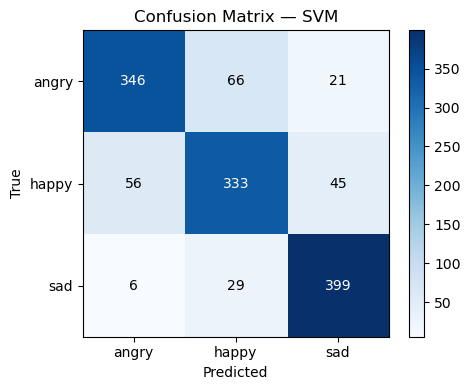

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=EMOTIONS)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(EMOTIONS)))
ax.set_yticks(range(len(EMOTIONS)))
ax.set_xticklabels(EMOTIONS)
ax.set_yticklabels(EMOTIONS)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix — SVM")

for i in range(len(EMOTIONS)):
    for j in range(len(EMOTIONS)):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.tight_layout()
plt.savefig("confusion_matrix_svm.png", dpi=150)
plt.show()

## Cross-Validation

In [ ]:
X_scaled  = StandardScaler().fit_transform(X)
cv_scores = cross_val_score(
    SVC(kernel="rbf", C=5, gamma="scale", random_state=RANDOM_SEED),
    X_scaled, y, cv=5, scoring="accuracy"
)

for i, s in enumerate(cv_scores, 1):
    print(f"Fold {i}: {s:.4f}")
print(f"\nMean: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}")

Fold 1: 0.4051
Fold 2: 0.7392
Fold 3: 0.7492
Fold 4: 0.7400
Fold 5: 0.6492

Mean: 0.6566  |  Std: 0.1309


In [ ]:
from sklearn.metrics import log_loss

y_proba = svm.predict_proba(X_test)
ll = log_loss(y_test, y_proba)
print(f"Log Loss: {ll:.4f}")

ModuleNotFoundError: No module named 'sklearn'